In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [5]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict
data = []
labels = []
for i in range(1, 6):
    batch = unpickle(fr"G:\AI\AI\Homework AI\lesson-30\homework\cifar-10-batches-py/data_batch_{i}")
    data.append(batch[b'data'])
    labels.extend(batch[b'labels'])
X_train = np.vstack(data).reshape(-1, 3, 32, 32)  # shape: (50000, 3, 32, 32)
y_train = np.array(labels)
test_batch = unpickle("cifar-10-batches-py/test_batch")
X_test = test_batch[b'data'].reshape(-1, 3, 32, 32)
y_test = np.array(test_batch[b'labels'])
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

df_labels = pd.DataFrame(y_train, columns=["label"])
print(df_labels.head())

Train: (50000, 3, 32, 32) (50000,)
Test : (10000, 3, 32, 32) (10000,)
   label
0      6
1      9
2      9
3      4
4      1


In [6]:
# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

1


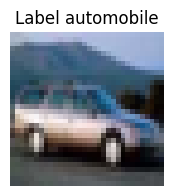

In [20]:
n=4
plt.figure(figsize=(2,2))
plt.axis('off')
plt.imshow(np.transpose(X_train[n], (1,2,0)))
y_label = y_train[n]
print(y_label)
plt.title(f'Label {class_names[y_label]}')
plt.show()

In [ ]:
from skimage.feature import hog
from skimage.transform import resize
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# The shape of your data is (N, C, H, W). HOG expects (N, H, W, C).
# We must transpose the arrays.
X_train_transposed = np.transpose(X_train, (0, 2, 3, 1))
X_test_transposed = np.transpose(X_test, (0, 2, 3, 1))

print("Transposed train shape:", X_train_transposed.shape)
print("Transposed test shape:", X_test_transposed.shape)

# Helper function to extract HOG features from a dataset
def extract_hog_features(images):
    features_list = []
    print("Extracting features...")
    for i, image in enumerate(images):
        if i % 1000 == 0:
            print(f"  Processing image {i}/{len(images)}...")
        
        # Resize image for better HOG feature extraction
        resized_img = resize(image, (64, 64))
        
        # HOG parameters
        hog_features = hog(resized_img, orientations=9, pixels_per_cell=(8, 8),
                           cells_per_block=(2, 2), transform_sqrt=True, block_norm='L2-Hys',
                           channel_axis=-1)
        features_list.append(hog_features)
    return np.array(features_list)

# We'll use a subset of the data for this example to make training faster
subset_size = 30000
X_train_subset = X_train_transposed[:subset_size]
y_train_subset = y_train[:subset_size]

print("\nExtracting HOG features from the training subset...")
X_train_hog = extract_hog_features(X_train_subset)

print("\nExtracting HOG features from the test set...")
X_test_hog = extract_hog_features(X_test_transposed)

print("\nShape of extracted HOG features:")
print("Training features:", X_train_hog.shape)
print("Test features:", X_test_hog.shape)

# Create a pipeline to scale data and train the SVM
print("\nTraining the SVM classifier...")
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
])

# Fit the model to the HOG features
svm_pipeline.fit(X_train_hog, y_train_subset)

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred = svm_pipeline.predict(X_test_hog)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nSVM classifier accuracy: {accuracy:.4f}")

Transposed train shape: (50000, 32, 32, 3)
Transposed test shape: (10000, 32, 32, 3)

Extracting HOG features from the training subset...
Extracting features...
  Processing image 0/30000...
  Processing image 1000/30000...
  Processing image 2000/30000...
  Processing image 3000/30000...
  Processing image 4000/30000...
  Processing image 5000/30000...
  Processing image 6000/30000...
  Processing image 7000/30000...
  Processing image 8000/30000...
  Processing image 9000/30000...
  Processing image 10000/30000...
  Processing image 11000/30000...
  Processing image 12000/30000...
  Processing image 13000/30000...
  Processing image 14000/30000...
  Processing image 15000/30000...
  Processing image 16000/30000...
  Processing image 17000/30000...
  Processing image 18000/30000...
  Processing image 19000/30000...
  Processing image 20000/30000...
  Processing image 21000/30000...
  Processing image 22000/30000...
  Processing image 23000/30000...
  Processing image 24000/30000...
  

In [ ]:
50000 ta rasm bor 10 guruhdan bittasi boladi, rasm berilsa qaysi bir guruhga kiradiganini aniqlash